In [10]:
##import and open photos, .csv files, and set up landmark lists
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

##open photos
photo_folder = 'data/image_folder' ##replace path with path to folder with photos to process
photos = []
undistorted_photos = []
num_photos = len(os.listdir(photo_folder))

##open .csv file with pose and timestep
pose_file = 'data/lab3_pose.csv' ##replace with path to .csv file with pose and timestep data
pose_data = np.genfromtxt(pose_file, delimiter=',', skip_header=1)
#1-idx, 2-px, 3-py, 4-pz, 5-qw, 6-qx, 7-qy, 8-qz
# print(f"pose data: {pose_data[8:12]}") ##check data input is correct from csv file
##landmark pixel coordinates
##must be within x=y= {-2, 2} [m] in body frame
landmark_px = []
landmark_body = []

In [2]:
##camera parameters from lab 3 document on quercus
K = np.matrix([[698.86, 0, 306.91],[0, 699.13, 150.34],[0, 0, 1]])
d = np.array([0.191887, -0.563680, -0.003676, -0.002037, 0])
Tcb = np.matrix([[1, -1, 0, 0],[-1, 0, 0, 0],[0, 0, -1, 0],[0, 0, 0, 1]])
Rcb = Tcb[:3, :3]

##Variables
threshold = 137
size = 500

In [3]:
##early image tester 
##loop through photos to undistort and find contours of landmarks
thresh_photos = [] ##clear cache
undistorted_photos = [] ##clear cache

for i in range(num_photos):
    #open photos and store in list
    photo_path = os.path.join(photo_folder, f'image_{i}.jpg')
    photo = cv2.imread(photo_path)
    photos.append(photo)

    ##apply camera distorion parameters and greyscale to photos
    photo = cv2.undistort(photo, K, d)
    photo = cv2.cvtColor(photo, cv2.COLOR_BGR2GRAY)
    photo = cv2.GaussianBlur(photo, (5, 5), 0)
    undistorted_photos.append(photo)
    # After Gaussian Blur, create a binary mask
    # Adjust 200 based on your lighting; pixels above 200 become white (255)
    ret, thresh = cv2.threshold(photo, threshold, 255, cv2.THRESH_BINARY)
    thresh_photos.append(thresh)



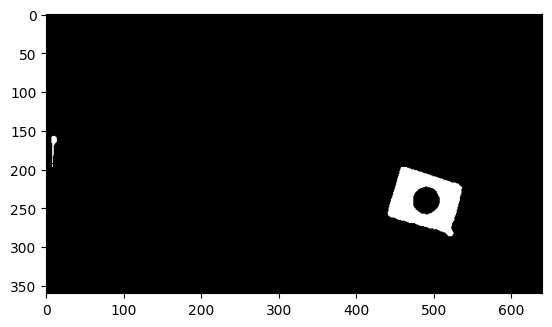

In [4]:
##show thresholded image to check if contours are visible
test_inner = 870
imgbrg = thresh_photos[test_inner]
imgrgb = cv2.cvtColor(imgbrg, cv2.COLOR_BGR2RGB)
plt.imshow(imgrgb)
plt.show()

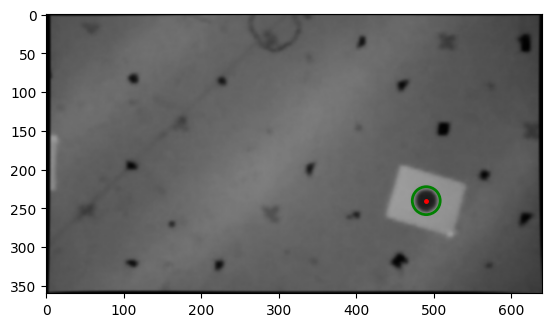

In [5]:
## find contour, identify circle, then plot the circle on the undistored photo
contours, hierarchy = cv2.findContours(thresh_photos[test_inner], cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
imgbrg = undistorted_photos[test_inner]
imgrgb = cv2.cvtColor(imgbrg, cv2.COLOR_BGR2RGB)
plt.imshow(imgrgb)
if hierarchy is not None and len(contours) > 0:
    for i, contour in enumerate(contours):
        
        # hierarchy[0][i] contains an array: [Next, Previous, First_Child, Parent]
        # We want to look at the 'Parent' index (which is at index 3)
        parent_idx = hierarchy[0][i][3]
        
        # 4. If parent_idx is NOT -1, it means this contour is INSIDE another contour
        if parent_idx != -1:
            
            # 5. Filter out tiny specks of noise that might be inside the square
            if cv2.contourArea(contour) > size: 
                
                # We found the inner dot! Calculate its circle.
                (x, y), radius = cv2.minEnclosingCircle(contour)
                center = (int(x), int(y))
                radius = int(radius)
                landmark_px.append(center)
                
                # draw the circle with matplotlib instead of cv2
                # (assumes the image has already been shown with plt.imshow
                #  – you can call plt.show() again after the loop to render
                #  the patches)
                circ = plt.Circle(center, radius,
                                  edgecolor='g', facecolor='none', linewidth=2)
                plt.gca().add_patch(circ)

                # optional: mark the exact centre with a red dot
                plt.plot(center[0], center[1], 'r.', markersize=5)

plt.show()

Processing image index: 500.0


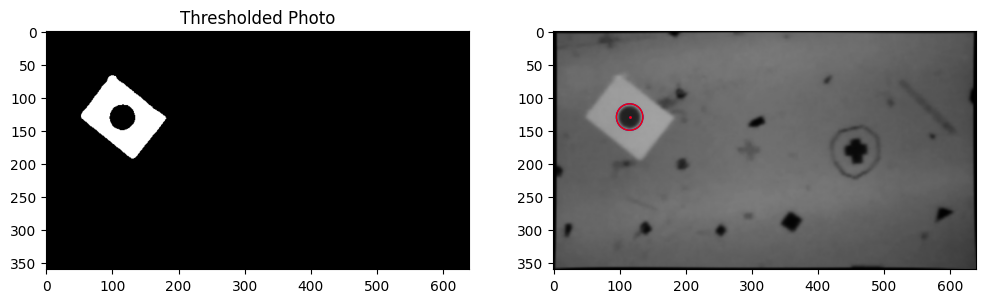

Processing image index: 571.4285714285714


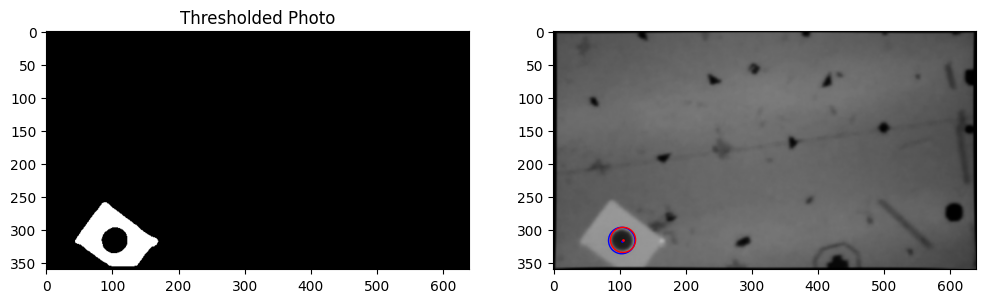

Processing image index: 642.8571428571429


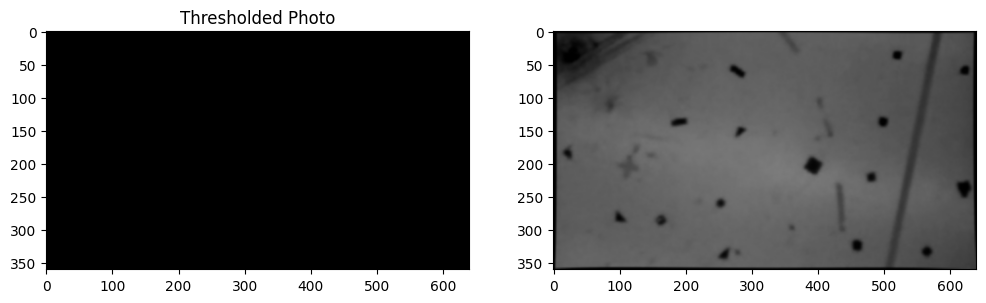

Processing image index: 714.2857142857142


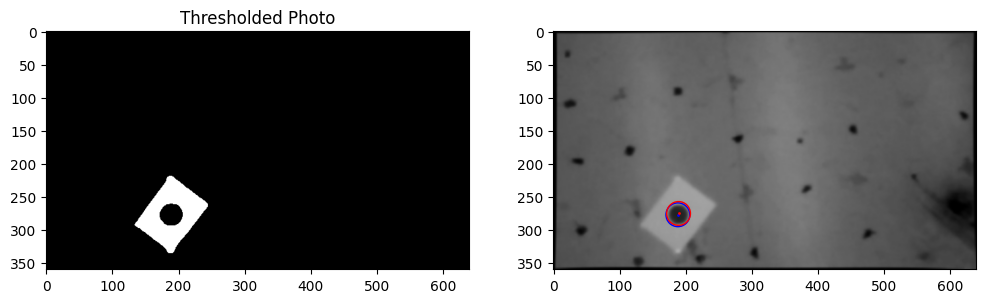

Processing image index: 785.7142857142858


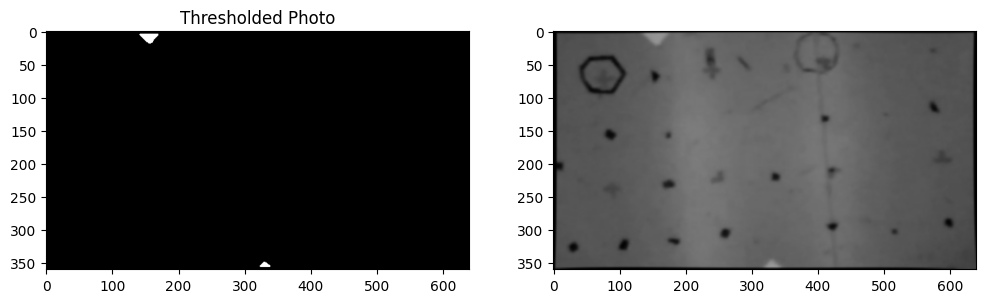

Processing image index: 857.1428571428571


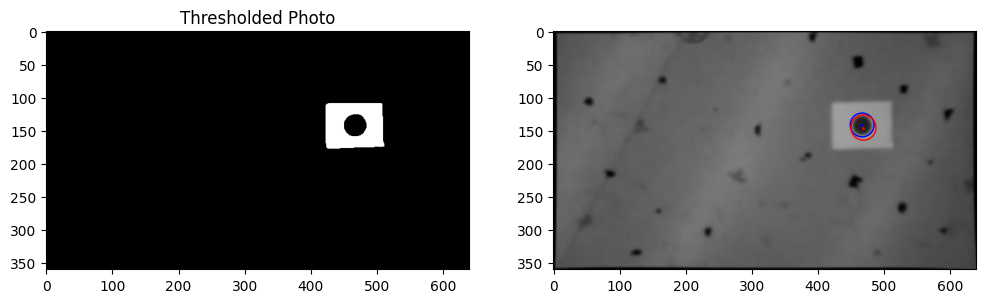

Processing image index: 928.5714285714286


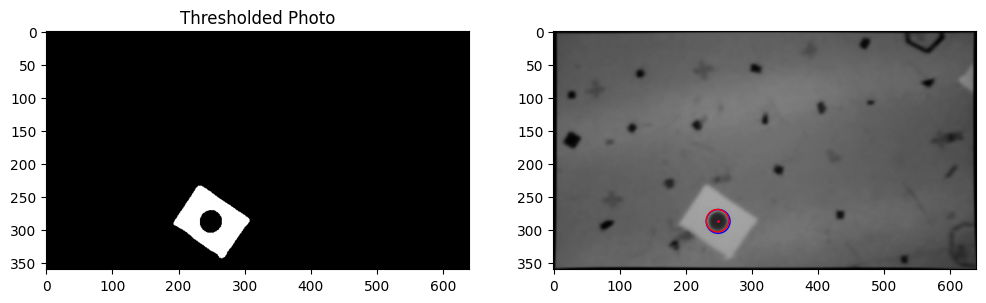

Processing image index: 1000.0


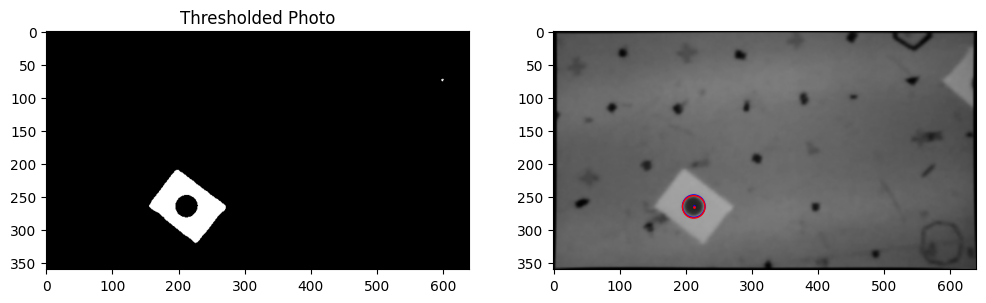

Processing image index: 1071.4285714285716


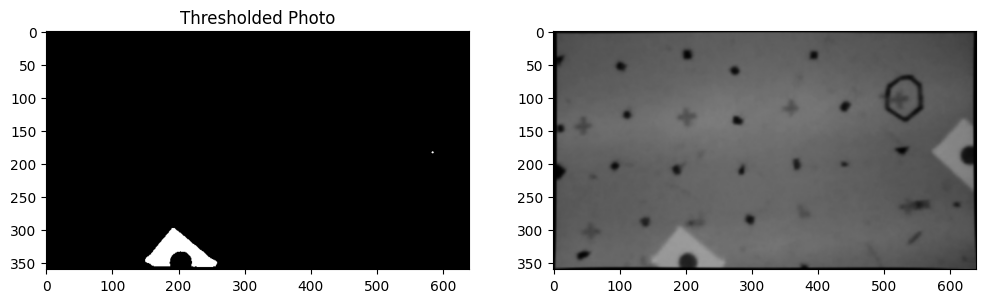

Processing image index: 1142.857142857143


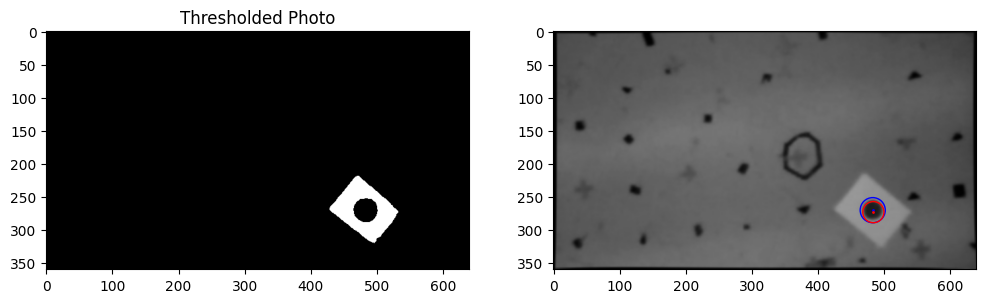

Processing image index: 1214.2857142857142


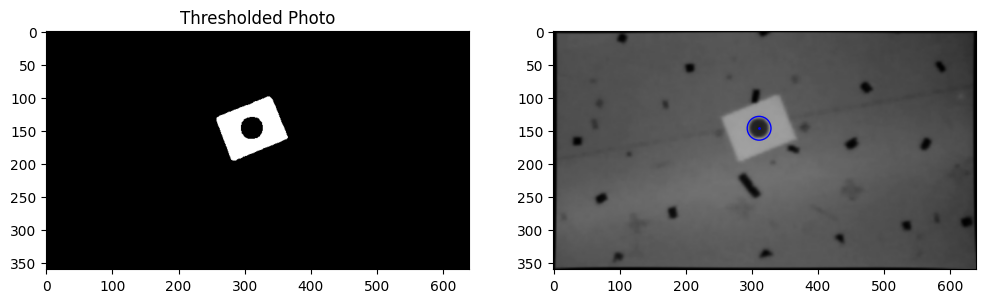

Processing image index: 1285.7142857142858


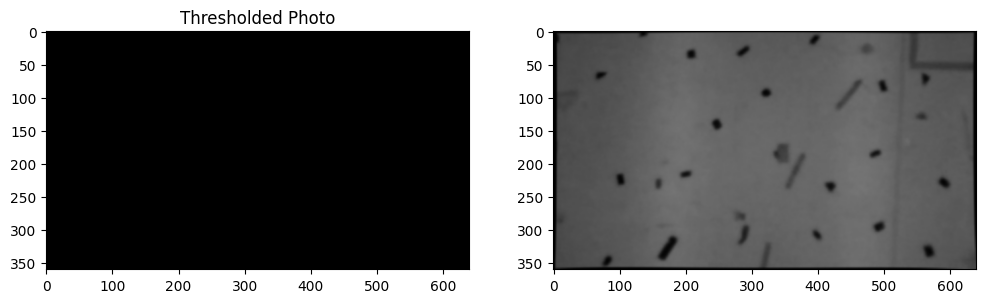

Processing image index: 1357.142857142857


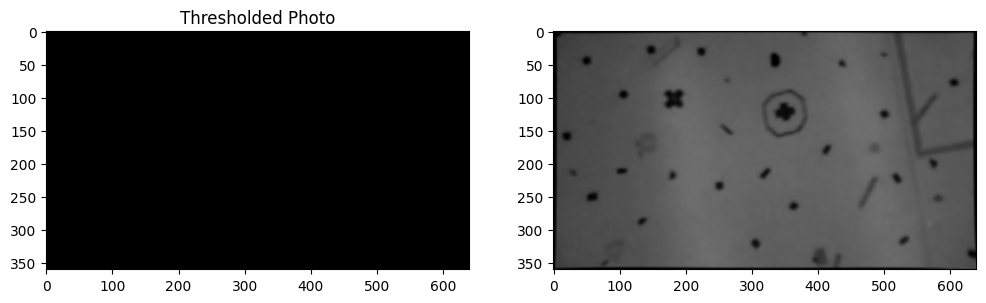

Processing image index: 1428.5714285714284


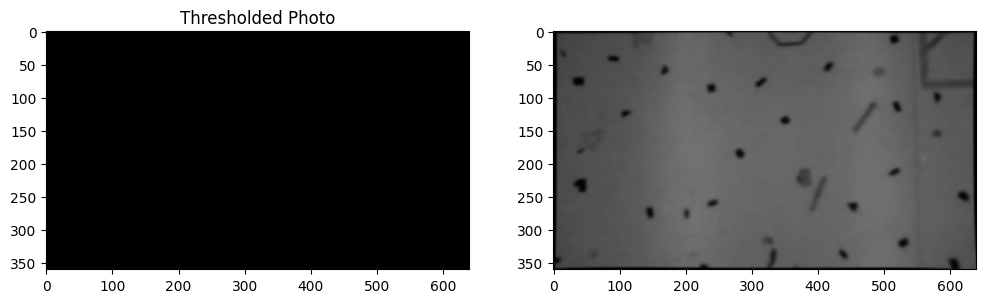

Processing image index: 1500.0


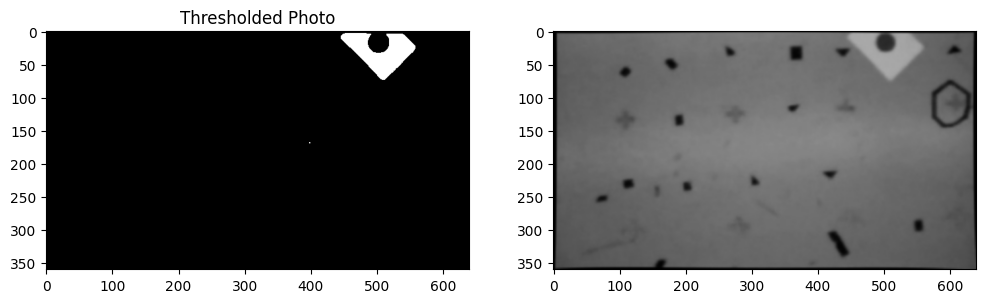

In [6]:
###ALL IN ONE MULTI PLOT VIEWER - hough vs threshold contour detection
##loop through photos to undistort and find contours of landmarks
#880, 512, 2696, 850, 2825
testing = np.linspace(500, 1500, 15)
# testing = np.linspace(2250,2407, 18) #indices of photos to test contour detection on
test_inner = 0
threshold = 137
size = 500
def detect_circles(img):
    circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, dp=1.2, minDist=20,
                               param1=50, param2=30, minRadius=5, maxRadius=500)
    if circles is not None:
        ##find the center and radius of the detected circle
        circles = np.round(circles[0, :]).astype("int")
        center = (circles[0][0], circles[0][1], circles[0][2]) ##x, y, radius

        return center
    else:
        return None
def plot_photos_with_contours(test_img, test_inner):
    thresh_photos = [] ##clear cache
    undistorted_photos = [] ##clear cache
    print(f"Processing image index: {test_img}")

    #open photos and store in list
    photo_path = os.path.join(photo_folder, f'image_{int(test_img)}.jpg')
    photo = cv2.imread(photo_path)
    photos.append(photo)

    ##apply camera distorion parameters and greyscale to photos
    photo = cv2.undistort(photo, K, d)
    photo = cv2.cvtColor(photo, cv2.COLOR_BGR2GRAY)
    photo = cv2.GaussianBlur(photo, (5, 5), 0)
    undistorted_photos.append(photo)
    # After Gaussian Blur, create a binary mask
    # Adjust 200 based on your lighting; pixels above 200 become white (255)
    ret, thresh = cv2.threshold(photo, threshold, 255, cv2.THRESH_BINARY)
    thresh_photos.append(thresh)
    #prepare 2 plots to show the undistorted photo and the thresholded photo side by side
    fig, axs = plt.subplots(1, 2, figsize=(12, 16))
    #plot thresh photo on left
    imgbrg = thresh_photos[test_inner]
    imgrgb = cv2.cvtColor(imgbrg, cv2.COLOR_BGR2RGB)
    axs[0].imshow(imgrgb)
    axs[0].set_title('Thresholded Photo')


    ## find contour, identify circle, then plot the circle on the undistored photo
    contours, hierarchy = cv2.findContours(thresh_photos[test_inner], cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if np.sum(thresh == 255) > 0.5 * thresh.size:
        print("Skipping image")
        hierarchy = None
    imgbrg = undistorted_photos[test_inner]
    imgrgb = cv2.cvtColor(imgbrg, cv2.COLOR_BGR2RGB)
    plt.imshow(imgrgb)
    if hierarchy is not None and len(contours) > 0:
        for i, contour in enumerate(contours):
            
            # hierarchy[0][i] contains an array: [Next, Previous, First_Child, Parent]
            # We want to look at the 'Parent' index (which is at index 3)
            parent_idx = hierarchy[0][i][3]
            
            # 4. If parent_idx is NOT -1, it means this contour is INSIDE another contour
            if parent_idx != -1:
                
                # 5. Filter out tiny specks of noise that might be inside the square
                if cv2.contourArea(contour) > size: 
                    
                    # We found the inner dot! Calculate its circle.
                    (x, y), radius = cv2.minEnclosingCircle(contour)
                    center = (int(x), int(y))
                    radius = int(radius)
                    houghCir = detect_circles(thresh_photos[test_inner])
                    if houghCir is not None:
                        ##save center and radius of hough circle
                        HCcenter = (houghCir[0], houghCir[1])
                        HCradius = houghCir[2]
                        ###check if hough circle is close to contour circle
                        dist = np.sqrt((houghCir[0] - center[0])**2 + (houghCir[1] - center[1])**2)
                        if dist <  10:
                            landmark_px.append(center)

                    # draw the circle with matplotlib instead of cv2
                    # (assumes the image has already been shown with plt.imshow
                    #  – you can call plt.show() again after the loop to render
                    #  the patches)
                    circ = plt.Circle(center, radius,
                                    edgecolor='b', facecolor='none', linewidth=1)
                    plt.gca().add_patch(circ)
                    plt.plot(center[0], center[1], 'b.', markersize=2)
                    if houghCir is not None:
                      plt.plot(HCcenter[0], HCcenter[1], 'r.', markersize=2)
                      houghcirc = plt.Circle(HCcenter, HCradius,
                                        edgecolor='r', facecolor='none', linewidth=1)
                      plt.gca().add_patch(houghcirc)

    #plot undistorted photo on right with circle mapped
    plt.show()
for j in range(len(testing)):
    plot_photos_with_contours(testing[j],test_inner)

In [7]:
##test drone pose
##load pose
row = 850
def extract_pose_from_csv_row(row):
    # 1. Extract Position
    px, py, pz = row[1], row[2], row[3]
    drone_pos = np.array([px, py, pz])
    
    # 2. Extract Quaternions and REORDER them to [x, y, z, w] for Scipy
    qw, qx, qy, qz = row[4], row[5], row[6], row[7]
    
    # 3. Create the Rotation Matrix
    # scipy expects the format [x, y, z, w]
    rotation = R.from_quat([qx, qy, qz, qw])
    R_body_to_world = rotation.as_matrix() # Returns a 3x3 numpy array
    
    return drone_pos, R_body_to_world
pose_test, Rbw = extract_pose_from_csv_row(pose_data[850])
# print(f"Drone Position (px, py, pz): {pose_test[0], pose_test[1], pose_test[2]}")
# print(f"Rotation Matrix (Body to World):\n{rot_test}")
for i in range(len(landmark_px)):
    print(f"Landmark {i} pixel coordinates: {landmark_px[i]}")
    print(f"Drone Position (px, py, pz): {pose_test[0], pose_test[1], pose_test[2]}")

    ##pixel to camera frame
    uv_vec = np.array([[landmark_px[i][0]], [landmark_px[i][1]], [1.0] ]) ##homogenous pixel coordinates
    ray_c = np.linalg.inv(K) @ uv_vec ##ray direction in camera frame
    # ray_direction = np.linalg.inv(K).dot(np.array([landmark_px[i][0], landmark_px[i][1], 1]))
    #ray_direction = Rcb.T.dot(np.array([landmark_px[i][0], landmark_px[i][1], 1]))

    ##body to world
    rcw = Rbw @ Rcb
    ray_w = rcw @ ray_c
    ray_w_flat = ray_w.flatten() ##flatten to 1D array for easier handling
    print(f"Landmark {i} ray direction in world frame: {ray_w}")

    # Extract the drone's Z altitude and the ray's Z direction
    drone_z = pose_test[2]
    ray_z = ray_w[2]

    # Calculate the scaling factor 's' to reach the ground (where Z = 0)
    s = -drone_z / ray_z 

    # Scale the entire ray vector and add it to the drone's position
    landmark_world_position = pose_test + (s * ray_w_flat)

    # Flatten the final result just to be absolutely safe
    landmark_world_position = np.asarray(landmark_world_position).flatten()# The result is a 3D point: [X, Y, Z]. Z should be very close to 0.
    
    final_x = landmark_world_position[0]
    final_y = landmark_world_position[1]

    print(f"Landmark {i} is located on the ground at: X = {final_x:.3f}m, Y = {final_y:.3f}m Z = {landmark_world_position[2]:.3f}m")
    

Landmark 0 pixel coordinates: (490, 240)
Drone Position (px, py, pz): (np.float64(-0.22717), np.float64(-1.39371), np.float64(2.14137))
Landmark 0 ray direction in world frame: [[ 0.19609115]
 [-0.2592993 ]
 [-0.99037048]]
Landmark 0 is located on the ground at: X = 0.197m, Y = -1.954m Z = 0.000m
Landmark 1 pixel coordinates: (115, 129)
Drone Position (px, py, pz): (np.float64(-0.22717), np.float64(-1.39371), np.float64(2.14137))
Landmark 1 ray direction in world frame: [[-0.34054698]
 [ 0.11825401]
 [-1.00251019]]
Landmark 1 is located on the ground at: X = -0.955m, Y = -1.141m Z = 0.000m
Landmark 2 pixel coordinates: (103, 316)
Drone Position (px, py, pz): (np.float64(-0.22717), np.float64(-1.39371), np.float64(2.14137))
Landmark 2 ray direction in world frame: [[-0.6142464 ]
 [ 0.03878818]
 [-0.99291573]]
Landmark 2 is located on the ground at: X = -1.552m, Y = -1.310m Z = 0.000m
Landmark 3 pixel coordinates: (188, 277)
Drone Position (px, py, pz): (np.float64(-0.22717), np.float64(

In [11]:
##Save everything as one big csv file - can run individually as one python script

import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
# from sklearn.cluster import KMeans

###CALIBRATED VALUES
threshold = 137
size = 500

##open photos
# photo_folder = '/Users/zoecrookshank/Desktop/MEng - UofT/AER1217/Lab3/output_folder'
photos = []
undistorted_photos = []
num_photos = len(os.listdir(photo_folder))

##open .csv file with pose and timestep
# pose_file = '/Users/zoecrookshank/Desktop/MEng - UofT/AER1217/Lab3/lab3_pose.csv'
pose_data = np.genfromtxt(pose_file, delimiter=',', skip_header=1)
#1-idx, 2-px, 3-py, 4-pz, 5-qw, 6-qx, 7-qy, 8-qz
# print(f"pose data: {pose_data[8:12]}") ##check data input is correct from csv file

##camera parameters from lab 3 document on quercus
K = np.matrix([[698.86, 0, 306.91],[0, 699.13, 150.34],[0, 0, 1]])
d = np.array([0.191887, -0.563680, -0.003676, -0.002037, 0])
Tcb = np.matrix([[1, -1, 0, 0],[-1, 0, 0, 0],[0, 0, -1, 0],[0, 0, 0, 1]])
# Rcb = Tcb[:3, :3]
Rcb = np.array([[0, -1, 0],
                [-1, 0, 0],
                [0,  0,-1]])

##landmark pixel coordinates
##must be within x=y= {-2, 2} [m] in body frame
landmark_px = []
landmark_world = []

##functions
## function to extract position and rotation matrix from .csv file
def extract_pose_from_csv_row(row):
    # 1. Extract Position
    px, py, pz = row[1], row[2], row[3]
    drone_pos = np.array([px, py, pz])
    
    # 2. Extract Quaternions and REORDER them to [x, y, z, w] for Scipy
    qw, qx, qy, qz = row[4], row[5], row[6], row[7]
    
    # 3. Create the Rotation Matrix
    rotation = R.from_quat([qx, qy, qz, qw])
    R_body_to_world = rotation.as_matrix() # Returns a 3x3 numpy array

    return drone_pos, R_body_to_world

def transform_pixel_to_body_frame(pixel, drone_pos, Rbw):
    ##pixel to camera frame
    uv_vec = np.array([ [pixel[0]], [pixel[1]], [1.0] ])##homogenous pixel coordinates
    ray_c = np.linalg.inv(K) @ uv_vec ##ray direction in camera frame
   
    ##body to world
    rcw = Rbw @ Rcb
    ray_w = rcw @ ray_c
    ray_w_flat = ray_w.flatten() ##flatten to 1D array 

    ##calculate the scaling factor s to reach the ground (z=0) in world frame
    drone_z = drone_pos[2]
    ray_z = ray_w[2]
    #ray_z = ray_w_flat[2] ##alternative way to get z component of ray in world frame
    s = -drone_z / ray_z 

    ##scale vector to ground plane
    landmark_world_position = drone_pos + (s * ray_w_flat)

    ##flatten the landmark world position to get X, Y, Z coordinates
    landmark_world_position = np.asarray(landmark_world_position).flatten()# The result is a 3D point: [X, Y, Z]. Z should be very close to 0.
    return landmark_world_position

for i in range(num_photos):
    ##extrac csv instance
    Drone_pose, Rbw = extract_pose_from_csv_row(pose_data[i])

    #open photos and store in list
    photo_path = os.path.join(photo_folder, f'image_{i}.jpg')
    photo = cv2.imread(photo_path)

    ##apply camera distorion parameters and greyscale to photos
    photo = cv2.undistort(photo, K, d)
    photo = cv2.cvtColor(photo, cv2.COLOR_BGR2GRAY)
    photo = cv2.GaussianBlur(photo, (5, 5), 0)
    undistorted_photos.append(photo)
    # After Gaussian Blur, create a binary mask using calibrated threshold
    ret, thresh = cv2.threshold(photo, threshold, 255, cv2.THRESH_BINARY)
    
    ##if >50% of image is white, error when floor is in frame during take-off while white balance adjusts
    ##skipping contour detection for this image
    if np.sum(thresh == 255) > 0.5 * thresh.size:
        # print(f"Skipping image index {i} due to excessive white pixels (off path)") 
        continue

    # Now find contours on the 'thresh' image
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    ##find contours in the heirarchy (contour inside a contour) to identify the inner dot of the landmark
    if hierarchy is not None and len(contours) > 0:
        for j, contour in enumerate(contours):
            
            # hierarchy[0][i] contains an array: [Next, Previous, First_Child, Parent]
            # We want to look at the 'Parent' index (which is at index 3)
            parent_idx = hierarchy[0][j][3]
            
            # 4. If parent_idx is NOT -1, it means this contour is INSIDE another contour
            if parent_idx != -1:
                
                # 5. Filter out tiny specks of noise that might be inside the square
                if cv2.contourArea(contour) > size: 
                    
                    # We found the inner dot! Calculate its circle.
                    (x, y), radius = cv2.minEnclosingCircle(contour)
                    center = (int(x), int(y))
                    radius = int(radius)
                    landmark_px.append([i, center, radius]) ##store the frame index, center, and radius of target
                    
                    ##transform pixel coordinates to world frame coordinates
                    landmark_w = transform_pixel_to_body_frame(center, Drone_pose, Rbw)
                    if landmark_w is not None:
                        tuple_landmark_w = (landmark_w[0], landmark_w[1], landmark_w[2], i) ##convert to tuple for easier storage
                        landmark_world.append(tuple_landmark_w) #append to list of world coordinates

##save list of landmark world coordinates to .csv file
landmark_world_array = np.array(landmark_world)
np.savetxt('landmark_world_coordinates.csv', landmark_world_array, delimiter=',', header='X,Y,Z,idx', comments='')


The above section details target localization and transforming the pixel locations into the world frame. you should now have a .csv file that contains these target locations along with the frame indexes. Now, outlier rejection, visualization, and confirming the 6 target locations:

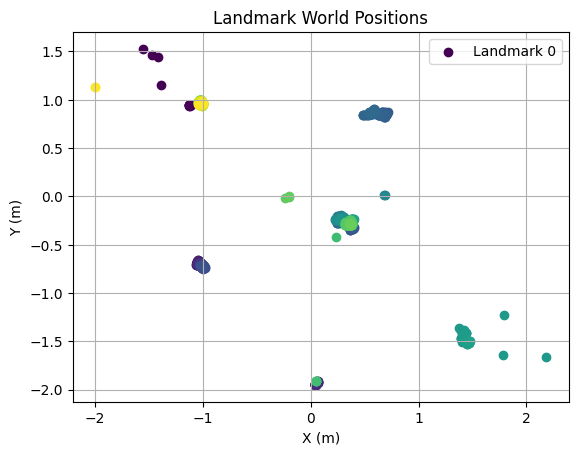

In [12]:
##plot scatter plot of all landmark world positions
land = 'landmark_world_coordinates.csv'
landmark_data = np.genfromtxt(land, delimiter=',', skip_header=1)
#scatter them in order of first to last - first blue last red
for i in range(len(landmark_data)):
    plt.scatter(landmark_data[i][0], landmark_data[i][1], color=plt.cm.viridis(i / len(landmark_data)), label=f'Landmark {i}')
    if i==0:
        plt.legend()  
plt.title('Landmark World Positions')
#add scale for colours
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.grid()
plt.show()

Centroids of the 6 clusters (landmarks):
Landmark 0: X = 0.364m, Y = -0.280m
Landmark 1: X = 0.267m, Y = -0.232m
Landmark 2: X = -1.033m, Y = 0.976m
Landmark 3: X = -1.027m, Y = -0.704m
Landmark 4: X = 0.630m, Y = 0.857m
Landmark 5: X = 0.896m, Y = -1.654m


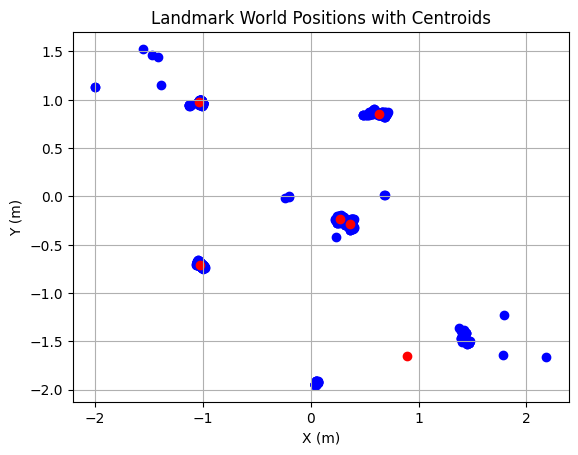

In [15]:
###identify 6 centroids from the scatter plot of landmark world positions and center them
# from sklearn.cluster import KMeans
# import numpy as np

from scipy.cluster.vq import vq, kmeans, whiten


scatter_x = landmark_data[:, 0]
scatter_y = landmark_data[:, 1]
scatter_points = np.column_stack((scatter_x, scatter_y))
centroids, distortion = kmeans(scatter_points, 6)
# kmeans = KMeans(n_clusters=6, random_state=0).fit(scatter_points)
# centroids = kmeans.cluster_centers_
print("Centroids of the 6 clusters (landmarks):")
for idx, centroid in enumerate(centroids):
    print(f"Landmark {idx}: X = {centroid[0]:.3f}m, Y = {centroid[1]:.3f}m")
plt.scatter(scatter_x, scatter_y, color='blue', label='Landmark Points')
plt.scatter(centroids[:, 0], centroids[:, 1], color='red', label='Centroids')
plt.title('Landmark World Positions with Centroids')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.grid()
plt.show()

In [31]:
def find_closest_centroid(clusters, point):
    min_dist = np.inf
    closest_centroid = None
    for cluster in clusters:
        dist = np.linalg.norm(cluster - point) 
        if dist < min_dist:
            min_dist = dist
            closest_centroid = cluster
    return closest_centroid, min_dist

def refine_centroids(initial_poses, start_number=10, final_number=6, dist_threshold=0.2):
    poses = initial_poses
    outlier_list = []

    xy_poses = initial_poses[:,0:2]
    codebook, distortion = kmeans(xy_poses, start_number)
    
    for i in range(start_number - final_number + 1):
        k = start_number - i
        print(k, " clusters")
        # apply outlier rejection
        inlier_list = []
        for pose in poses:
            xy_pose = pose[0:2]
            closest_centroid, dist = find_closest_centroid(codebook, xy_pose)
            if dist < dist_threshold:
                inlier_list.append(pose)
            else:
                outlier_list.append(pose)
        poses = np.array(inlier_list).reshape(-1,4)
        # re-apply k-means clustering
        xy_poses = poses[:,0:2]
        codebook, distortion = kmeans(xy_poses, k)

    selected_inliers = np.array(poses).reshape((-1,len(initial_poses[0])))
    outlier_list = np.array(outlier_list).reshape((-1,len(initial_poses[0])))
    return codebook, distortion, selected_inliers, outlier_list



In [76]:
codebook, distortion, poses, outliers = refine_centroids(landmark_data, start_number=10, final_number=6, dist_threshold=0.2)

10  clusters
9  clusters
8  clusters
7  clusters
6  clusters


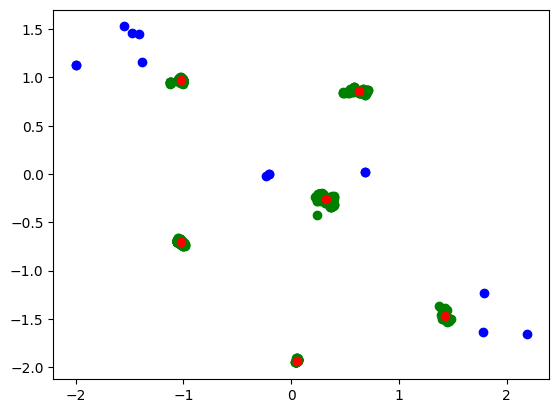

In [77]:

plt.scatter(poses[:, 0], poses[:, 1], c='g')
plt.scatter(codebook[:, 0], codebook[:, 1], c='r')
plt.scatter(outliers[:, 0], outliers[:, 1], c='b')
plt.show()

In [78]:
for idx, centroid in enumerate(codebook):
    print(f"Landmark {idx}: X = {centroid[0]:.3f}m, Y = {centroid[1]:.3f}m")

Landmark 0: X = 1.431m, Y = -1.471m
Landmark 1: X = 0.051m, Y = -1.930m
Landmark 2: X = 0.630m, Y = 0.857m
Landmark 3: X = -1.027m, Y = -0.704m
Landmark 4: X = -1.023m, Y = 0.970m
Landmark 5: X = 0.323m, Y = -0.261m


In [79]:
print(len(outliers))
print(len(poses))
print(landmark_data.shape)
print(landmark_data.shape[0] - len(poses))

14
1493
(1507, 4)
14


In [80]:
def plot_detected_markers(axes, img_idx):
    #open photos and store in list
    photo_path = os.path.join(photo_folder, f'image_{img_idx}.jpg')
    photo = cv2.imread(photo_path)

    ##apply camera distorion parameters and greyscale to photos
    photo = cv2.undistort(photo, K, d)
    photo = cv2.cvtColor(photo, cv2.COLOR_BGR2GRAY)
    photo = cv2.GaussianBlur(photo, (5, 5), 0)
    # After Gaussian Blur, create a binary mask using calibrated threshold
    ret, thresh = cv2.threshold(photo, threshold, 255, cv2.THRESH_BINARY)
    
    ##if >50% of image is white, error when floor is in frame during take-off while white balance adjusts
    ##skipping contour detection for this image
    if np.sum(thresh == 255) > 0.5 * thresh.size:
        print(f"Skipping image index {img_idx} due to excessive white pixels (off path)") 
        return

    # Now find contours on the 'thresh' image
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    axes[0].imshow(photo, cmap='gray')
    axes[1].imshow(thresh, cmap='gray')
    ##find contours in the heirarchy (contour inside a contour) to identify the inner dot of the landmark
    if hierarchy is not None and len(contours) > 0:
        for j, contour in enumerate(contours):
            
            # hierarchy[0][i] contains an array: [Next, Previous, First_Child, Parent]
            # We want to look at the 'Parent' index (which is at index 3)
            parent_idx = hierarchy[0][j][3]
            
            # 4. If parent_idx is NOT -1, it means this contour is INSIDE another contour
            if parent_idx != -1:
                
                # 5. Filter out tiny specks of noise that might be inside the square
                if cv2.contourArea(contour) > size: 
                    
                    # We found the inner dot! Calculate its circle.
                    (x, y), radius = cv2.minEnclosingCircle(contour)
                    center = (int(x), int(y))
                    radius = int(radius)

                    circ = plt.Circle(center, radius, edgecolor='g', facecolor='none', linewidth=2)
                    axes[1].add_patch(circ)
    
                    # optional: mark the exact centre with a red dot
                    axes[1].plot(center[0], center[1], 'r.', markersize=5)

14
156


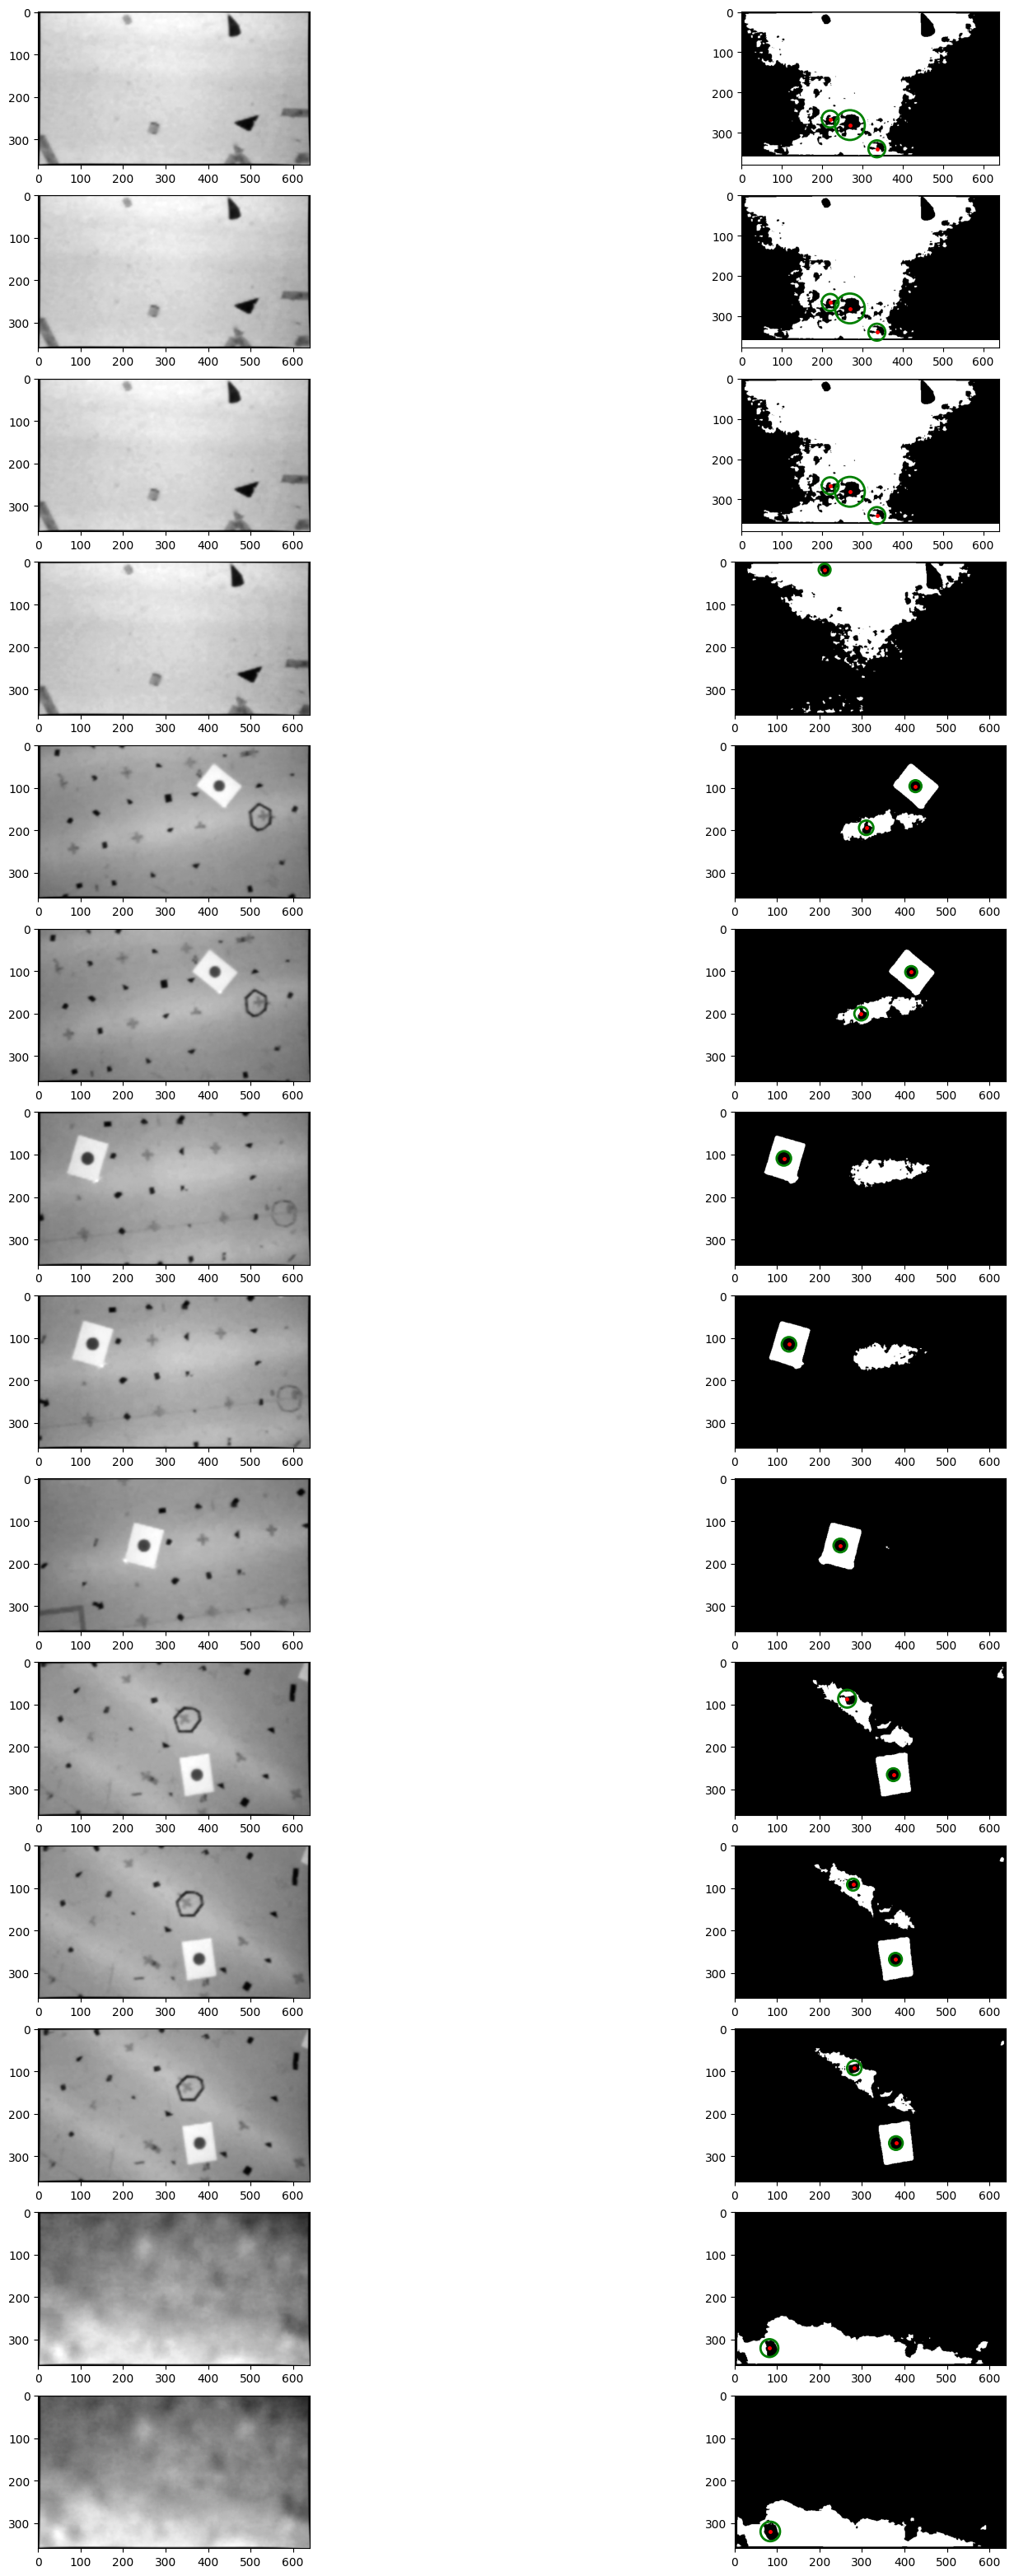

In [81]:
outlier_img_numbers = (outliers[:,3]).astype(np.uint16)
num_images = len(outlier_img_numbers.flatten())
print(num_images)
print(outlier_img_numbers[0])
fig, plot_axes = plt.subplots(num_images, 2, figsize=(20, 40))

for i in range(0, num_images):
    plot_detected_markers(plot_axes[i], outlier_img_numbers[i])
plt.show()